# Multivariate Cox Regression — Genes + Clinical Variables (R)

A single joint `coxph` model combining penalised-Cox selected genes with clinical
covariates (tumor size, ER status, lymph node status, tumor grade). Identifies
which genes remain significant after adjusting for clinical factors.

**Risk score** = Σ βᵢ × expressionᵢ (significant genes only)

**Depends on:** `penalized_cox_sig_genes_train.csv` (from `penalized_cox_r.ipynb`)

**Libraries:** `survival`, `survminer`, `ggplot2`, `pheatmap`, `ggpubr`

In [4]:
# install.packages(c('survival','survminer','ggplot2','dplyr','pheatmap','ggpubr','scales'))

In [5]:
suppressPackageStartupMessages({
  library(survival)
  library(survminer)
  library(ggplot2)
  library(dplyr)
  library(pheatmap)
  library(scales)
  library(ggpubr)
})

DATA_DIR <- '../../datasets/csv_files'
VIS_DIR  <- '../../visuals'
dir.create(VIS_DIR, showWarnings = FALSE, recursive = TRUE)
message('Packages loaded.')

Warning message:
"package 'survminer' was built under R version 4.5.3"


Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'ggpubr' was built under R version 4.5.3"
Warning message:
"package 'pheatmap' was built under R version 4.5.3"
Warning message:
"package 'scales' was built under R version 4.5.3"
Packages loaded.



## Preparing Data

In [6]:
expr <- read.csv(file.path(DATA_DIR, 'penalized_cox_sig_genes_train.csv'), stringsAsFactors = FALSE)
clinical <- read.csv(file.path(DATA_DIR, 'clinical_metadata_train.csv'),       stringsAsFactors = FALSE)

test1 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_one.csv'),   stringsAsFactors = FALSE)
test2 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_two.csv'),   stringsAsFactors = FALSE)
test3 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_three.csv'), stringsAsFactors = FALSE)

for (nm in c('test1','test2','test3')) {
  df <- get(nm)
  assign(nm, df[complete.cases(df[c('relapse_free_time','relapse_free_event')]), ])
}

cat(sprintf('Test 1: %d | Test 2: %d | Test 3: %d patients\n',
            nrow(test1), nrow(test2), nrow(test3)))
clinical[1:5, ]

Test 1: 244 | Test 2: 88 | Test 3: 117 patients


,sample_name,is_tumor,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,GSM1045191,0,NA,NA,NA,NA,NA,NA,NA
2,GSM1045192,0,NA,NA,NA,NA,NA,NA,NA
3,GSM1045193,0,NA,NA,NA,NA,NA,NA,NA
4,GSM1045194,0,NA,NA,NA,NA,NA,NA,NA
5,GSM1045195,0,NA,NA,NA,NA,NA,NA,NA


In [7]:
surv_cols    <- c('sample_name', 'relapse_free_event', 'relapse_free_time')
clinical_sel <- c('sample_name','relapse_free_event','relapse_free_time',
                  'tumor_size','er_status','lymph_node_status','tumor_grade')
gene_cols    <- setdiff(names(expr), surv_cols)
cat(sprintf('%d gene columns: %s\n', length(gene_cols), paste(gene_cols, collapse=', ')))

expr_genes <- expr[, c('sample_name', gene_cols)]
train_data <- merge(clinical[, clinical_sel], expr_genes, by = 'sample_name')
train_data <- train_data[complete.cases(train_data), ]
train_data$relapse_free_event <- as.integer(train_data$relapse_free_event)

cat(sprintf('Training patients with complete gene + clinical data: %d\n', nrow(train_data)))
head(train_data)

24 gene columns: SOX4, KLHL5, DEFB132, FBXL16, MICB, UBE2S, MTHFD1, ARF1, S100P, CEBPD, TF, SOD2, POLR3GL, BLNK, PRLR, FBXL5, COLEC12, CFB, MDK, EVL, STAT5A, UBE2E3, CXCL14, TRIM45
Training patients with complete gene + clinical data: 101


,sample_name,relapse_free_event,relapse_free_time,tumor_size,er_status,lymph_node_status,tumor_grade,SOX4,KLHL5,DEFB132,⋯,PRLR,FBXL5,COLEC12,CFB,MDK,EVL,STAT5A,UBE2E3,CXCL14,TRIM45
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,GSM1045208,0,3026,0,1,1,2,7.735311,4.727495,3.001555,⋯,5.409960,7.780658,7.359875,7.205254,6.349483,9.176116,7.169852,5.809944,11.798407,6.428617
2,GSM1045209,1,755,5,1,1,2,7.967062,4.202276,3.119509,⋯,5.118496,7.242231,5.794930,7.136334,7.848696,7.921031,6.309295,5.596044,6.697138,6.394637
3,GSM1045210,0,3014,3,1,0,1,8.076291,4.771116,2.982960,⋯,5.396281,7.540444,7.039614,7.301934,7.003300,8.894975,6.531898,5.575941,11.618586,6.074443
4,GSM1045211,1,406,1,1,1,3,7.511513,3.711394,2.820621,⋯,4.227421,6.171535,6.681315,5.207979,6.749071,8.815157,6.227280,5.128132,9.092684,5.916733
5,GSM1045212,0,2225,2,0,0,3,7.601258,4.633546,2.851260,⋯,4.102159,7.167023,6.241178,6.896423,8.426718,6.811868,7.649678,8.221396,5.977753,6.681431
6,GSM1045213,1,252,5,0,1,3,7.811726,4.369779,3.033343,⋯,4.281331,6.989108,6.263570,6.025503,6.641281,7.634397,7.270909,6.958520,8.670685,5.647433


## Multivariate Cox: Genes + Clinical Variables

Single model combining all penalised-Cox genes with clinical covariates.
Identifies which genes remain significant after adjusting for tumor size,
ER status, lymph node status, and tumor grade.

In [8]:
clinical_covars <- c('tumor_size','er_status','lymph_node_status','tumor_grade')
all_covars      <- c(gene_cols, clinical_covars)
formula_str     <- sprintf('Surv(relapse_free_time, relapse_free_event) ~ %s',
                           paste(sprintf('`%s`', all_covars), collapse = ' + '))
cph <- coxph(as.formula(formula_str), data = train_data)

s     <- summary(cph)
coefs <- s$coefficients
ci    <- s$conf.int

all_results <- data.frame(
  gene        = rownames(coefs),
  beta        = round(coefs[, 'coef'],        4),
  HR          = round(ci[,   'exp(coef)'],    4),
  HR_lower_95 = round(ci[,   'lower .95'],    4),
  HR_upper_95 = round(ci[,   'upper .95'],    4),
  p_value     = round(coefs[, 'Pr(>|z|)'],   4),
  stringsAsFactors = FALSE, row.names = NULL
)
all_results <- all_results[order(all_results$p_value), ]
cat('All results (sorted by p-value):\n')
all_results

All results (sorted by p-value):


,gene,beta,HR,HR_lower_95,HR_upper_95,p_value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27,lymph_node_status,1.7008,5.4781,1.6367,18.3354,0.0058
9,S100P,0.2470,1.2802,1.0451,1.5682,0.0170
4,FBXL16,-0.9806,0.3751,0.1511,0.9311,0.0345
25,tumor_size,0.3455,1.4127,1.0197,1.9573,0.0378
6,UBE2S,0.6095,1.8396,1.0343,3.2718,0.0380
2,KLHL5,-1.3261,0.2655,0.0682,1.0338,0.0559
5,MICB,-0.3503,0.7045,0.4796,1.0348,0.0741
14,BLNK,-0.3417,0.7106,0.4754,1.0620,0.0956
3,DEFB132,-1.4459,0.2355,0.0371,1.4936,0.1250


In [9]:
sig_genes_df <- all_results[
  all_results$p_value < 0.05 & all_results$gene %in% gene_cols, ]
sig_genes_df$role <- ifelse(sig_genes_df$HR > 1, 'danger', 'protective')
sig_genes <- sig_genes_df$gene

cat(strrep('=', 50), '\n')
cat(sprintf('Total covariates tested:      %d\n', nrow(all_results)))
cat(sprintf('Significant genes (p < 0.05): %d\n', length(sig_genes)))
cat(strrep('=', 50), '\n')
sig_genes_df[, c('gene','beta','HR','HR_lower_95','HR_upper_95','p_value','role')]

Total covariates tested:      28
Significant genes (p < 0.05): 3


,gene,beta,HR,HR_lower_95,HR_upper_95,p_value,role
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
9,S100P,0.2470,1.2802,1.0451,1.5682,0.0170,danger
4,FBXL16,-0.9806,0.3751,0.1511,0.9311,0.0345,protective
6,UBE2S,0.6095,1.8396,1.0343,3.2718,0.0380,danger


In [10]:
cat('Clinical variables:\n')
print(all_results[all_results$gene %in% clinical_covars, c('gene','HR','p_value')])

PAPER_GENES <- c('TSLP','BIRC5','S100B','MDK','S100P','RARRES3','BLNK','ACO1')
in_paper  <- intersect(sig_genes, PAPER_GENES)
not_paper <- setdiff(sig_genes, PAPER_GENES)
missing   <- setdiff(PAPER_GENES, sig_genes)
cat(sprintf('\nPaper overlap : %d/%d  %s\n', length(in_paper),
            length(PAPER_GENES), paste(in_paper, collapse=', ')))
cat(sprintf('Novel genes   : %s\n', paste(not_paper, collapse=', ')))
cat(sprintf('Missing       : %s\n', paste(missing,   collapse=', ')))

Clinical variables:
                gene     HR p_value
27 lymph_node_status 5.4781  0.0058
25        tumor_size 1.4127  0.0378
28       tumor_grade 0.6317  0.3106
26         er_status 0.6236  0.4104

Paper overlap : 1/8  S100P
Novel genes   : FBXL16, UBE2S
Missing       : TSLP, BIRC5, S100B, MDK, RARRES3, BLNK, ACO1


## Forest Plot — All Covariates

Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.
`height` was translated to `width`.


Saved: multivariate_forest_plot.png


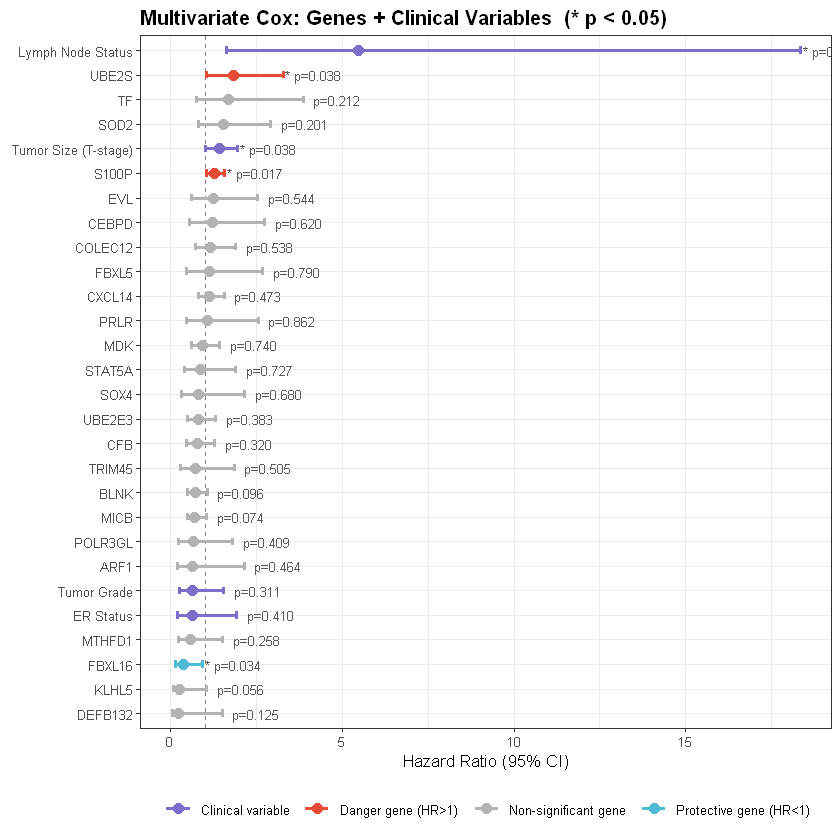

In [11]:
label_map  <- c(tumor_size='Tumor Size (T-stage)', er_status='ER Status',
                lymph_node_status='Lymph Node Status', tumor_grade='Tumor Grade')
plot_df    <- all_results[order(all_results$HR), ]
plot_df$label <- ifelse(plot_df$gene %in% names(label_map),
                        label_map[plot_df$gene], plot_df$gene)
plot_df$label <- factor(plot_df$label, levels = plot_df$label)
plot_df$cgrp  <- case_when(
  plot_df$gene %in% clinical_covars                       ~ 'clinical',
  plot_df$gene %in% sig_genes & plot_df$HR > 1            ~ 'danger',
  plot_df$gene %in% sig_genes & plot_df$HR <= 1           ~ 'protective',
  TRUE                                                    ~ 'ns'
)
pal <- c(danger='#E64B35', protective='#4DBBD5', clinical='#7E6ECC', ns='grey70')

p_forest <- ggplot(plot_df, aes(x=HR, y=label, colour=cgrp)) +
  geom_vline(xintercept=1, linetype='dashed', colour='black', alpha=0.5) +
  geom_errorbarh(aes(xmin=HR_lower_95, xmax=HR_upper_95), height=0.3, linewidth=1.1) +
  geom_point(size=2.8) +
  geom_text(aes(x=HR_upper_95,
                label=ifelse(p_value<0.05, sprintf('* p=%.3f',p_value),
                                           sprintf('  p=%.3f',p_value))),
            hjust=-0.05, size=2.7, colour='grey35') +
  scale_colour_manual(values=pal, name='',
    labels=c(danger='Danger gene (HR>1)', protective='Protective gene (HR<1)',
             clinical='Clinical variable', ns='Non-significant gene')) +
  labs(title='Multivariate Cox: Genes + Clinical Variables  (* p < 0.05)',
       x='Hazard Ratio (95% CI)', y=NULL) +
  theme_bw(base_size=10) +
  theme(plot.title=element_text(face='bold'), legend.position='bottom')

p_forest
ggsave(file.path(VIS_DIR, 'multivariate_forest_plot.png'), p_forest,
       dpi=150, width=10, height=max(5, nrow(plot_df)*0.38))
cat('Saved: multivariate_forest_plot.png\n')

## Compute Risk Score

In [12]:
# Risk Score = sum(beta_i * expression_i) for significant genes
# Betas come from the combined multivariate Cox model
compute_risk_scores <- function(df, results_df, genes,
                                time_col='relapse_free_time', event_col='relapse_free_event') {
  beta_vec <- setNames(results_df$beta, results_df$gene)
  common   <- intersect(intersect(genes, names(beta_vec)), names(df))
  risk     <- as.vector(as.matrix(df[, common]) %*% beta_vec[common])
  out_cols <- intersect(c('sample_name', time_col, event_col), names(df))
  out      <- df[, out_cols, drop=FALSE]
  out$risk_score <- risk
  cat(sprintf('  %d patients | range [%.4f, %.4f] | mean %.4f\n',
              nrow(out), min(risk), max(risk), mean(risk)))
  out
}

if (length(sig_genes) == 0) {
  cat('No significant genes — using all gene_cols.\n')
  sig_genes    <- gene_cols
  sig_genes_df <- all_results[all_results$gene %in% gene_cols, ]
}

cat(sprintf('Computing risk scores using %d genes: %s\n',
            length(sig_genes), paste(sig_genes, collapse=', ')))
train_scores <- compute_risk_scores(train_data, all_results, sig_genes)
test1_scores <- compute_risk_scores(test1,      all_results, sig_genes)
test2_scores <- compute_risk_scores(test2,      all_results, sig_genes)
test3_scores <- compute_risk_scores(test3,      all_results, sig_genes)

Computing risk scores using 3 genes: S100P, FBXL16, UBE2S
  101 patients | range [-1.5367, 3.4118] | mean 0.2571
  244 patients | range [-1.9969, 4.0577] | mean 1.1656
  88 patients | range [-0.3751, 4.5381] | mean 2.0591
  117 patients | range [-1.6875, 3.4660] | mean 0.5741


## Gene Signature Visualisations

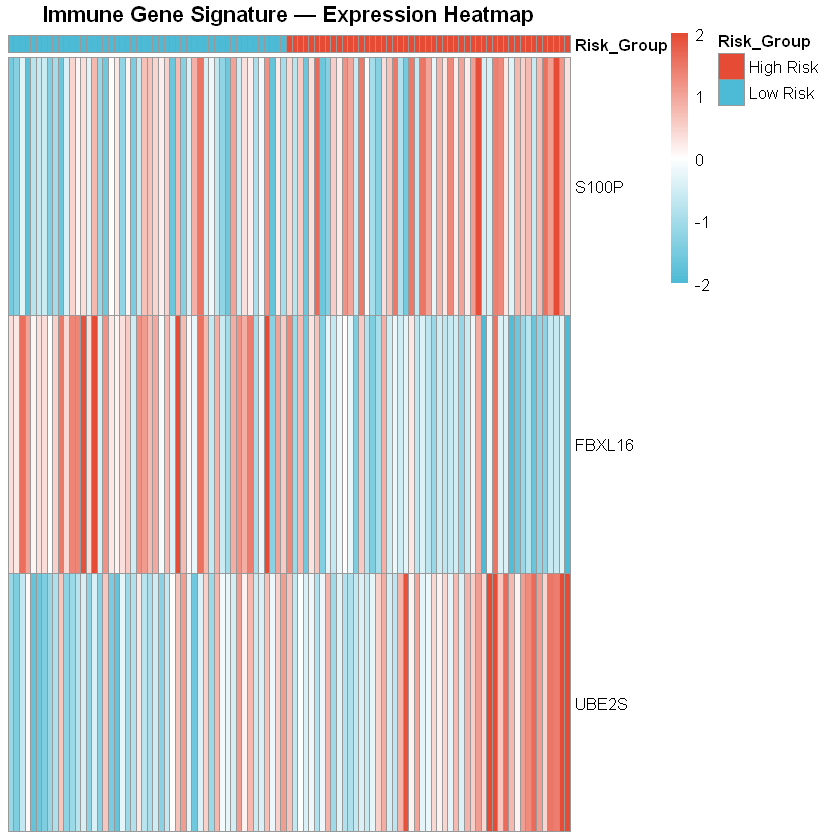

In [17]:
train_median <- median(train_scores$risk_score)
risk_label   <- function(scores, cutoff) ifelse(scores >= cutoff, 'High Risk', 'Low Risk')
groups_train <- risk_label(train_scores$risk_score, train_median)

sort_idx     <- order(train_scores$risk_score)
sorted_groups <- groups_train[sort_idx]
expr_mat      <- as.matrix(train_data[sort_idx, sig_genes, drop=FALSE])
expr_z <- t(scale(expr_mat))
rownames(expr_z) <- sig_genes
n_pts           <- nrow(expr_mat)
colnames(expr_z) <- paste0('P', seq_len(n_pts))

ann_col    <- data.frame(Risk_Group=sorted_groups, row.names=colnames(expr_z))
ann_colors <- list(Risk_Group=c('High Risk'='#E64B35','Low Risk'='#4DBBD5'))

pheatmap(expr_z, cluster_cols=FALSE, cluster_rows=FALSE,
         annotation_col=ann_col, annotation_colors=ann_colors,
         color=colorRampPalette(c('#4DBBD5','white','#E64B35'))(100),
         breaks=seq(-2,2,length.out=101),
         show_colnames=FALSE, fontsize_row=10,
         main='Immune Gene Signature — Expression Heatmap')

In [ ]:
long_df <- do.call(rbind, lapply(sig_genes, function(g)
  data.frame(gene=g, expression=train_data[[g]],
             risk_group=groups_train, stringsAsFactors=FALSE)))

ggplot(long_df, aes(x=risk_group, y=expression, fill=risk_group)) +
  geom_violin(alpha=0.65, trim=FALSE) +
  geom_jitter(width=0.08, alpha=0.4, size=1.0) +
  stat_summary(fun=median, geom='crossbar', width=0.45, colour='black', fatten=1.5) +
  scale_fill_manual(values=c('High Risk'='#E64B35','Low Risk'='#4DBBD5'), guide='none') +
  facet_wrap(~gene, scales='free_y') +
  labs(title='Signature Gene Expression: High vs Low Risk',
       x=NULL, y='Expression (log2)') +
  theme_bw(base_size=9) +
  theme(plot.title=element_text(face='bold'), strip.text=element_text(face='bold'))

## Patient Stratification (High vs Low Risk)

Training median risk score (cutoff): 0.0919


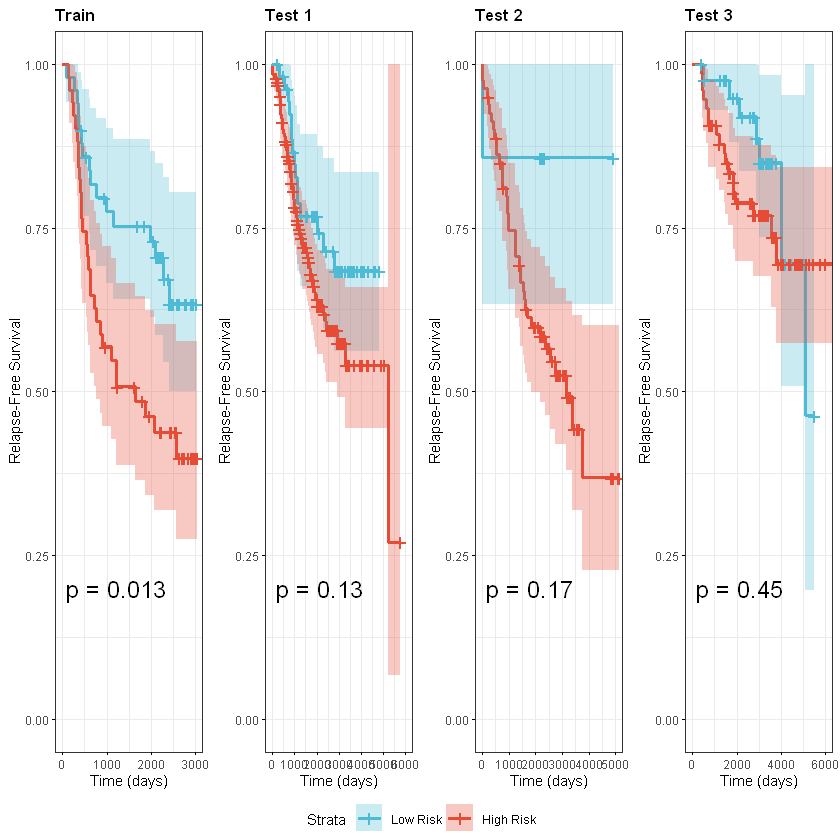

In [16]:
cat(sprintf('Training median risk score (cutoff): %.4f\n', train_median))

km_plot <- function(scores_df, title, cutoff) {
  df_km <- data.frame(
    time  = as.numeric(scores_df$relapse_free_time),
    event = as.integer(scores_df$relapse_free_event),
    group = factor(risk_label(scores_df$risk_score, cutoff),
                   levels=c('Low Risk','High Risk'))
  )
  df_km <- df_km[complete.cases(df_km), ]
  fit   <- survfit(Surv(time, event) ~ group, data=df_km)
  ggsurvplot(fit, data=df_km, pval=TRUE, conf.int=TRUE,
             palette=c('Low Risk'='#4DBBD5','High Risk'='#E64B35'),
             title=title, xlab='Time (days)', ylab='Relapse-Free Survival',
             legend.labs=c('Low Risk','High Risk'),
             ggtheme=theme_bw(base_size=9))$plot +
    theme(plot.title=element_text(face='bold', size=10))
}

score_sets <- list(
  list(scores=train_scores, label='Train'),
  list(scores=test1_scores, label='Test 1'),
  list(scores=test2_scores, label='Test 2'),
  list(scores=test3_scores, label='Test 3')
)
km_plots <- lapply(score_sets, function(x) km_plot(x$scores, x$label, train_median))
ggarrange(plotlist=km_plots, ncol=4, common.legend=TRUE, legend='bottom')

In [18]:
ggsave(file.path(VIS_DIR, 'multivariate_km_stratification.png'),
       ggarrange(plotlist=km_plots, ncol=4, common.legend=TRUE, legend='bottom'),
       dpi=150, width=20, height=5)
cat('Saved: multivariate_km_stratification.png\n')

Saved: multivariate_km_stratification.png


## Save Results

In [19]:
write.csv(all_results,  file.path(DATA_DIR, 'multivariate_cox_all_train.csv'),  row.names=FALSE)
write.csv(sig_genes_df, file.path(DATA_DIR, 'multivariate_cox_sig_train.csv'), row.names=FALSE)

save_risk <- function(scores_df, path, cutoff) {
  out <- scores_df
  out$risk_group <- risk_label(scores_df$risk_score, cutoff)
  write.csv(out, path, row.names=FALSE)
}
save_risk(train_scores, file.path(DATA_DIR, 'cox_risk_scores_train.csv'),     train_median)
save_risk(test1_scores, file.path(DATA_DIR, 'cox_risk_scores_test_one.csv'),  train_median)
save_risk(test2_scores, file.path(DATA_DIR, 'cox_risk_scores_test_two.csv'),  train_median)
save_risk(test3_scores, file.path(DATA_DIR, 'cox_risk_scores_test_three.csv'),train_median)

cat('Saved: multivariate_cox_all_train.csv, multivariate_cox_sig_train.csv\n')
cat('Saved: cox_risk_scores_{train, test_one, test_two, test_three}.csv\n')

Saved: multivariate_cox_all_train.csv, multivariate_cox_sig_train.csv
Saved: cox_risk_scores_{train, test_one, test_two, test_three}.csv
